# Tietjen-Moore Test for Multiple Outliers

The **Tietjen-Moore test** extends Grubbs's test to handle exactly k suspected outliers simultaneously. Unlike sequential Grubbs application, it removes all k suspects at once, avoiding the masking problem.

| Property | Value |
|---|---|
| **H₀** | The k most extreme values are not outliers |
| **H₁** | Exactly k outliers are present |
| **Test statistic** | Lₖ = Σᵢ(xᵢ−x̄ₖ)² / Σᵢ(xᵢ−x̄)² where x̄ₖ excludes the k suspects |
| **Critical value** | Obtained by simulation |
| **Requirement** | Must specify k in advance |
| **Alternative** | Generalised ESD test if k is unknown |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

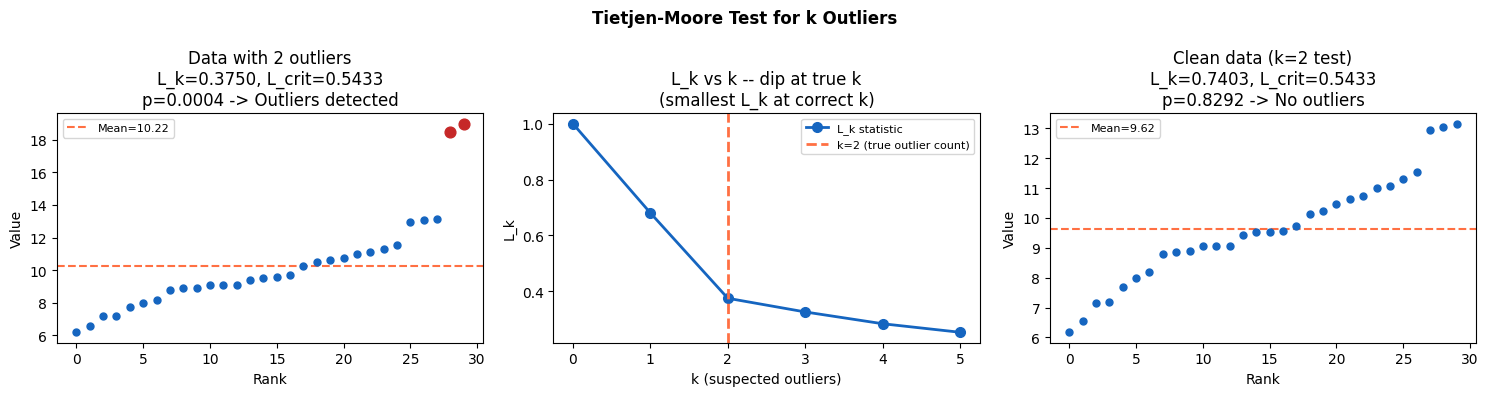

Contaminated data (k=2): L_k=0.3750, L_crit=0.5433, p=0.0004
Clean data (k=2):        L_k=0.7403, L_crit=0.5433, p=0.8292


In [2]:
def tietjen_moore(data, k, n_sim=5000, alpha=0.05, seed=0):
    np.random.seed(seed)
    n = len(data)
    mean_all = data.mean()
    dists = np.abs(data - mean_all)
    extreme_idx = np.argsort(dists)[-k:]
    remaining = np.delete(data, extreme_idx)
    mean_k = remaining.mean()
    L_k = np.sum((remaining - mean_k)**2) / np.sum((data - mean_all)**2)
    L_sims = []
    mean_s, std_s = data.mean(), data.std(ddof=1)
    for _ in range(n_sim):
        sim = np.random.normal(mean_s, std_s, n)
        m_all = sim.mean()
        d = np.abs(sim - m_all)
        rem = np.delete(sim, np.argsort(d)[-k:])
        m_k = rem.mean()
        L_sims.append(np.sum((rem - m_k)**2) / np.sum((sim - m_all)**2))
    L_crit = np.percentile(L_sims, alpha * 100)
    p_val = np.mean(np.array(L_sims) <= L_k)
    return L_k, L_crit, p_val, extreme_idx

np.random.seed(42)
n = 30
base = np.random.normal(10, 2, n)
data_2out = base.copy()
data_2out[5]  = 19.0
data_2out[22] = 18.5

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Tietjen-Moore Test for k Outliers', fontsize=12, fontweight='bold')

# Panel 1: k=2 on contaminated data
k = 2
L_k, L_crit, p_val, out_idx = tietjen_moore(data_2out, k)
sorted_data = np.sort(data_2out)
out_vals = set(data_2out[out_idx])
colors = ['#C62828' if v in out_vals else '#1565C0' for v in sorted_data]
for i, (v, c) in enumerate(zip(sorted_data, colors)):
    axes[0].scatter(i, v, color=c, s=60 if c=='#C62828' else 25, zorder=3)
axes[0].axhline(data_2out.mean(), color='#FF7043', lw=1.5, ls='--', label=f'Mean={data_2out.mean():.2f}')
decision_1 = 'Outliers detected' if L_k < L_crit else 'No outliers'
axes[0].set_title(f'Data with 2 outliers\nL_k={L_k:.4f}, L_crit={L_crit:.4f}\np={p_val:.4f} -> {decision_1}')
axes[0].set_xlabel('Rank'); axes[0].set_ylabel('Value')
axes[0].legend(fontsize=8)

# Panel 2: L_k statistic for different k on contaminated data
k_vals = range(0, 6)
L_vals = []
for ki in k_vals:
    if ki == 0:
        L_vals.append(1.0)
    else:
        L_ki, _, _, _ = tietjen_moore(data_2out, ki, n_sim=1000)
        L_vals.append(L_ki)
axes[1].plot(list(k_vals), L_vals, 'o-', color='#1565C0', lw=2, ms=7, label='L_k statistic')
axes[1].axvline(2, color='#FF7043', lw=2, ls='--', label='k=2 (true outlier count)')
axes[1].set_title('L_k vs k -- dip at true k\n(smallest L_k at correct k)')
axes[1].set_xlabel('k (suspected outliers)'); axes[1].set_ylabel('L_k')
axes[1].legend(fontsize=8)

# Panel 3: clean data for comparison
L_clean, L_crit_c, p_clean, _ = tietjen_moore(base, k)
sorted_clean = np.sort(base)
axes[2].scatter(range(n), sorted_clean, color='#1565C0', s=25, zorder=3)
axes[2].axhline(base.mean(), color='#FF7043', lw=1.5, ls='--', label=f'Mean={base.mean():.2f}')
axes[2].set_title(f'Clean data (k={k} test)\nL_k={L_clean:.4f}, L_crit={L_crit_c:.4f}\np={p_clean:.4f} -> No outliers')
axes[2].set_xlabel('Rank'); axes[2].set_ylabel('Value')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()
print(f'Contaminated data (k=2): L_k={L_k:.4f}, L_crit={L_crit:.4f}, p={p_val:.4f}')
print(f'Clean data (k=2):        L_k={L_clean:.4f}, L_crit={L_crit_c:.4f}, p={p_clean:.4f}')

## Key Takeaways

| | |
|---|---|
| **Small L_k → reject** | Unlike most tests — small statistic means outliers are present |
| **k must be specified** | Limitation: you must guess k; use ESD test if unsure |
| **No masking** | Removes all k suspects simultaneously — Grubbs sequential removal masks outliers |
| **Simulated critical values** | No closed-form; bootstrap/simulation required |
| **Dip in L_k vs k** | Scan k=1,2,...; smallest L_k relative to baseline identifies true k |
| **vs ESD** | ESD tests k=1,2,...,r sequentially and stops — preferred when k is unknown |